# TIGER Challenge — Segmentation Track: Exploratory Data Analysis
## With S3FS Streaming (Direct from AWS, No Download Needed)

**Track:** Tissue segmentation (tumor / stroma / rest)
**Dataset:** Streamed directly from `s3://tiger-training/` using anonymous S3 access via `s3fs`
**Source:** TIGER Grand Challenge (IEEE SPS GS MSP Cup 2024)

### What this notebook does
1. Connects to `s3://tiger-training/` anonymously via `s3fs` (same method as the Detection EDA)
2. Discovers PNG files and **separates images from masks** using a pixel-value heuristic
   (segmentation masks only contain small integer label values 0–7; real H&E images don't)
3. Runs **basic corrupted-file checks**
4. Applies the official **7-class → 3-class remapping**: `[0→0, 1→1, 2→2, 3→0, 4→0, 5→0, 6→2, 7→0]`
   where `0=Rest, 1=Tumor, 2=Stroma`
5. Computes **pixel-level class distribution** (critical for deciding class-weighted loss during UNet training)
6. Visualizes sample image / mask / overlay triplets
7. Checks image-mask size consistency and source breakdown

### Known from the official pipeline (not an open question — already decided by the paper)
The TIGER segmentation baseline explicitly uses:
- 256×256 patches
- ImageNet mean/std normalization
- **Explicit H&E stain normalization** (unlike detection, this one is NOT optional/open — it's part of the documented baseline)

This EDA is mainly to confirm class imbalance severity (for loss weighting) and catch any corrupted/mismatched files — not to decide whether stain norm is needed, since that's already settled for this track.

> **Note:** Run this in **Google Colab**.


## Step 0 — Setup: install & import libraries

In [ ]:
!pip install -q s3fs fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 24.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.


In [ ]:
import os
import re
import random
from io import BytesIO
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import s3fs

random.seed(42)
np.random.seed(42)


## Step 1 — Connect to S3 anonymously

Same approach as the Detection EDA notebook: `s3fs.S3FileSystem(anon=True)` for read-only,
credential-free access to the public `tiger-training` bucket.


In [ ]:
BUCKET_ROOT = "tiger-training/wsirois/roi-level-annotations"

s3 = s3fs.S3FileSystem(anon=True)

print("Connected to S3 (anonymous, read-only).")
print(f"Checking bucket root: {BUCKET_ROOT}")

try:
    top_level = s3.ls(BUCKET_ROOT)
    print(f"\n✓ Found {len(top_level)} items under {BUCKET_ROOT}:")
    for item in top_level[:30]:
        print(f"  {item}")
except Exception as e:
    print(f"Could not list {BUCKET_ROOT}: {e}")
    print("Trying the bucket root instead...")
    print(s3.ls("tiger-training"))


Connected to S3 (anonymous, read-only).
Checking bucket root: tiger-training/wsirois/roi-level-annotations

✓ Found 2 items under tiger-training/wsirois/roi-level-annotations:
  tiger-training/wsirois/roi-level-annotations/tissue-bcss
  tiger-training/wsirois/roi-level-annotations/tissue-cells


## Step 2 — Discover all PNG files, then separate images from masks

Both ROI images and tissue masks are PNGs, often in different subfolders, but we don't want to
hardcode folder names in case they differ slightly from documentation. Instead we discover
every PNG, then classify each one as **image** or **mask** using a pixel-value heuristic:
segmentation masks only contain small integer labels (0–7), while real H&E images have full-range
RGB values. This is more robust than trusting folder names alone.


In [ ]:
print("Discovering all PNG files (this may take a minute)...")
all_png = s3.glob(f"{BUCKET_ROOT}/**/*.png")
print(f"Found {len(all_png)} total PNG files")

print("\nSample paths:")
for p in all_png[:5]:
    print(f"  {p}")


Discovering all PNG files (this may take a minute)...
Found 4061 total PNG files

Sample paths:
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images/TCGA-A1-A0SK-01Z-00-DX1.A44D70FA-4D96-43F4-9DD7-A61535786297_[22877, 12530, 24892, 13993].png
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images/TCGA-A1-A0SP-01Z-00-DX1.20D689C6-EFA5-4694-BE76-24475A89ACC0_[3401, 26862, 6276, 28896].png
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images/TCGA-A2-A04P-01Z-00-DX1.5B481E02-D269-4732-8FDD-6494E6EE2B71_[52125, 24261, 54392, 26004].png
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images/TCGA-A2-A04Q-01Z-00-DX1.DF7ED6B6-7701-486D-9007-F26B6F0682C4_[10436, 8904, 11520, 9986].png
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images/TCGA-A2-A04T-01Z-00-DX1.71444266-BD56-4183-9603-C7AC20C9DA1E_[36075, 19541, 39828, 21434].png


In [ ]:
def classify_png(s3_path, sample_pixels=2000):
    """
    Classify a PNG as 'mask' or 'image' by inspecting its pixel values.
    Masks: single-channel or palette mode, values confined to 0-7.
    Images: RGB with full-range pixel values.
    """
    try:
        with s3.open(s3_path, 'rb') as f:
            img_bytes = f.read()
        im = Image.open(BytesIO(img_bytes))

        if im.mode in ('L', 'P', '1', 'I'):
            arr = np.asarray(im.convert('L'))
            unique_vals = np.unique(arr)
            if len(unique_vals) <= 10 and unique_vals.max() <= 10:
                return 'mask'
        # Fall back: check if RGB channels are all identical (indicates it's really a mask saved as RGB)
        elif im.mode == 'RGB':
            arr = np.asarray(im.convert('L'))
            unique_vals = np.unique(arr)
            if len(unique_vals) <= 10 and unique_vals.max() <= 10:
                return 'mask'
        return 'image'
    except Exception as e:
        return f'error: {str(e)[:50]}'

# Classify a sample first (classifying all files individually over the network is slow -
# we use path patterns learned from the sample to classify the rest quickly)
sample_size = min(60, len(all_png))
sample_paths = random.sample(all_png, sample_size)

classifications = {}
for p in tqdm(sample_paths, desc="Classifying sample PNGs"):
    classifications[p] = classify_png(p)

print("\nSample classification results:")
print(Counter(classifications.values()))


Classifying sample PNGs:   0%|          | 0/60 [00:00<?, ?it/s]


Sample classification results:
Counter({'image': 36, 'mask': 24})


In [ ]:
# Use folder-path patterns learned from the classified sample to fast-classify the rest
mask_dirs = set()
image_dirs = set()

for path, label in classifications.items():
    d = os.path.dirname(path)
    if label == 'mask':
        mask_dirs.add(d)
    elif label == 'image':
        image_dirs.add(d)

print(f"Directories identified as containing MASKS: {len(mask_dirs)}")
for d in list(mask_dirs)[:5]:
    print(f"  {d}")
print(f"\nDirectories identified as containing IMAGES: {len(image_dirs)}")
for d in list(image_dirs)[:5]:
    print(f"  {d}")

# Classify all remaining PNGs by directory membership; anything ambiguous gets pixel-checked directly
all_masks = []
all_images = []
ambiguous = []

for p in all_png:
    d = os.path.dirname(p)
    if d in mask_dirs and d not in image_dirs:
        all_masks.append(p)
    elif d in image_dirs and d not in mask_dirs:
        all_images.append(p)
    else:
        ambiguous.append(p)

print(f"\nFast-classified: {len(all_masks)} masks, {len(all_images)} images")
print(f"Ambiguous (need direct pixel check): {len(ambiguous)}")

for p in tqdm(ambiguous, desc="Resolving ambiguous files"):
    label = classify_png(p)
    if label == 'mask':
        all_masks.append(p)
    elif label == 'image':
        all_images.append(p)

print(f"\n✓ FINAL: {len(all_masks)} masks, {len(all_images)} images")


Directories identified as containing MASKS: 1
  tiger-training/wsirois/roi-level-annotations/tissue-cells/masks

Directories identified as containing IMAGES: 2
  tiger-training/wsirois/roi-level-annotations/tissue-cells/images
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images

Fast-classified: 1879 masks, 2031 images
Ambiguous (need direct pixel check): 151


Resolving ambiguous files:   0%|          | 0/151 [00:00<?, ?it/s]


✓ FINAL: 2030 masks, 2031 images


## Step 3 — Basic corrupted-file checks

Verify masks and images are all readable, and check that every mask has a matching image
(by matching on the shared ROI coordinate/filename stem).


In [ ]:
def strip_suffix(fname):
    """Remove common mask-related suffixes to help match mask<->image pairs by stem"""
    base = os.path.basename(fname)
    base = re.sub(r'\.(png|PNG)$', '', base)
    base = re.sub(r'(_mask|_tissue|_label)$', '', base, flags=re.IGNORECASE)
    return base

corrupted = []
for p in tqdm(all_masks + all_images, desc="Verifying files are readable"):
    try:
        with s3.open(p, 'rb') as f:
            img_bytes = f.read()
        im = Image.open(BytesIO(img_bytes))
        im.verify()
    except Exception as e:
        corrupted.append((p, str(e)[:60]))

print(f"✓ Checked {len(all_masks) + len(all_images)} files")
print(f"  Corrupted/unreadable files: {len(corrupted)}")
for c in corrupted[:10]:
    print(f"    {c}")


Verifying files are readable:   0%|          | 0/4061 [00:00<?, ?it/s]

✓ Checked 4061 files
  Corrupted/unreadable files: 0


In [ ]:
# Match masks to images by filename stem
image_stems = {strip_suffix(p): p for p in all_images}
mask_stems = {strip_suffix(p): p for p in all_masks}

matched = set(image_stems) & set(mask_stems)
unmatched_masks = set(mask_stems) - set(image_stems)
unmatched_images = set(image_stems) - set(mask_stems)

print(f"Matched image-mask pairs: {len(matched)}")
print(f"Masks with no matching image: {len(unmatched_masks)}")
print(f"Images with no matching mask: {len(unmatched_images)}")


Matched image-mask pairs: 2030
Masks with no matching image: 0
Images with no matching mask: 1


## Step 4 — Apply the official 7-class → 3-class remapping

Per the TIGER documentation:

| Original label | Meaning | Remapped to |
|---|---|---|
| 0 | ROI/background | 0 (Rest) |
| 1 | Invasive Tumor | 1 (Tumor) |
| 2 | Tumor-Associated Stroma | 2 (Stroma) |
| 3 | In-Situ Tumor | 0 (Rest) |
| 4 | Healthy Glands | 0 (Rest) |
| 5 | Necrosis Not In-Situ | 0 (Rest) |
| 6 | Inflamed Stroma | 2 (Stroma) |
| 7 | Rest (misc tissue) | 0 (Rest) |

Remap: `{0:0, 1:1, 2:2, 3:0, 4:0, 5:0, 6:2, 7:0}`


In [ ]:
REMAP = {0: 0, 1: 1, 2: 2, 3: 0, 4: 0, 5: 0, 6: 2, 7: 0}
CLASS_NAMES = {0: 'Rest', 1: 'Tumor', 2: 'Stroma'}

def remap_mask(mask_arr):
    remapped = np.zeros_like(mask_arr)
    for orig, new in REMAP.items():
        remapped[mask_arr == orig] = new
    return remapped

def load_mask(s3_path):
    with s3.open(s3_path, 'rb') as f:
        img_bytes = f.read()
    im = Image.open(BytesIO(img_bytes)).convert('L')
    return np.asarray(im)

# Quick sanity check on one mask
sample_mask_path = next(iter(mask_stems.values()))
raw_mask = load_mask(sample_mask_path)
print(f"Sample mask: {sample_mask_path}")
print(f"Unique raw label values: {np.unique(raw_mask)}")
remapped_sample = remap_mask(raw_mask)
print(f"Unique remapped label values: {np.unique(remapped_sample)}")


Sample mask: tiger-training/wsirois/roi-level-annotations/tissue-cells/masks/100B_[10779, 11621, 12102, 12874].png
Unique raw label values: [0 4 7]
Unique remapped label values: [0]


## Step 5 — Pixel-level class distribution (for loss weighting decisions)

We sample a subset of masks, remap them, and tally pixel counts per class across the dataset.
Severe class imbalance here (e.g. very little Tumor relative to Rest) would justify weighted
loss or focal loss during UNet training.


In [ ]:
SAMPLE_SIZE = min(150, len(mask_stems))
sampled_stems = random.sample(list(mask_stems.keys()), SAMPLE_SIZE)

class_pixel_counts = Counter()
per_image_class_presence = []

for stem in tqdm(sampled_stems, desc="Tallying class pixels"):
    mask_path = mask_stems[stem]
    try:
        raw = load_mask(mask_path)
        remapped = remap_mask(raw)
        vals, counts = np.unique(remapped, return_counts=True)
        for v, c in zip(vals, counts):
            class_pixel_counts[int(v)] += int(c)
        per_image_class_presence.append({
            'stem': stem,
            'has_tumor': bool((remapped == 1).any()),
            'has_stroma': bool((remapped == 2).any()),
        })
    except Exception:
        continue

total_pixels = sum(class_pixel_counts.values())
print("Pixel-level class distribution (sampled):")
for cls_id, name in CLASS_NAMES.items():
    count = class_pixel_counts.get(cls_id, 0)
    pct = 100 * count / total_pixels if total_pixels else 0
    print(f"  {name} (label={cls_id}): {count:,} pixels ({pct:.2f}%)")


Tallying class pixels:   0%|          | 0/150 [00:00<?, ?it/s]

Pixel-level class distribution (sampled):
  Rest (label=0): 21,265,630 pixels (34.41%)
  Tumor (label=1): 21,294,946 pixels (34.46%)
  Stroma (label=2): 19,243,458 pixels (31.14%)


Images containing Tumor pixels: 107 / 150
Images containing Stroma pixels: 124 / 150


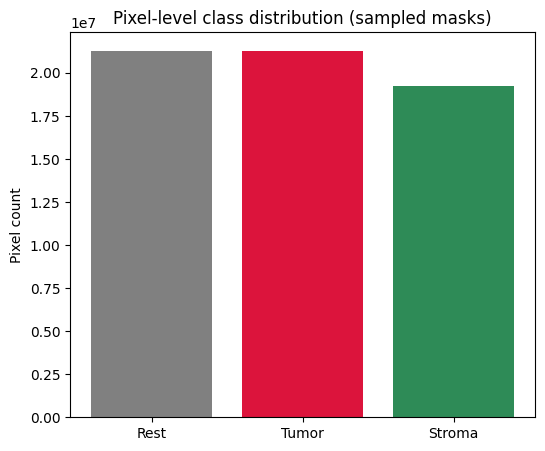

In [ ]:
presence_df = pd.DataFrame(per_image_class_presence)
print(f"Images containing Tumor pixels: {presence_df['has_tumor'].sum()} / {len(presence_df)}")
print(f"Images containing Stroma pixels: {presence_df['has_stroma'].sum()} / {len(presence_df)}")

# Visualize class balance
plt.figure(figsize=(6, 5))
names = [CLASS_NAMES[k] for k in sorted(class_pixel_counts.keys())]
counts = [class_pixel_counts[k] for k in sorted(class_pixel_counts.keys())]
plt.bar(names, counts, color=['gray', 'crimson', 'seagreen'])
plt.title('Pixel-level class distribution (sampled masks)')
plt.ylabel('Pixel count')
plt.show()


## Step 6 — Visualize image / mask / overlay triplets

Same visualization style as the official pipeline slide: original image, remapped mask, overlay.


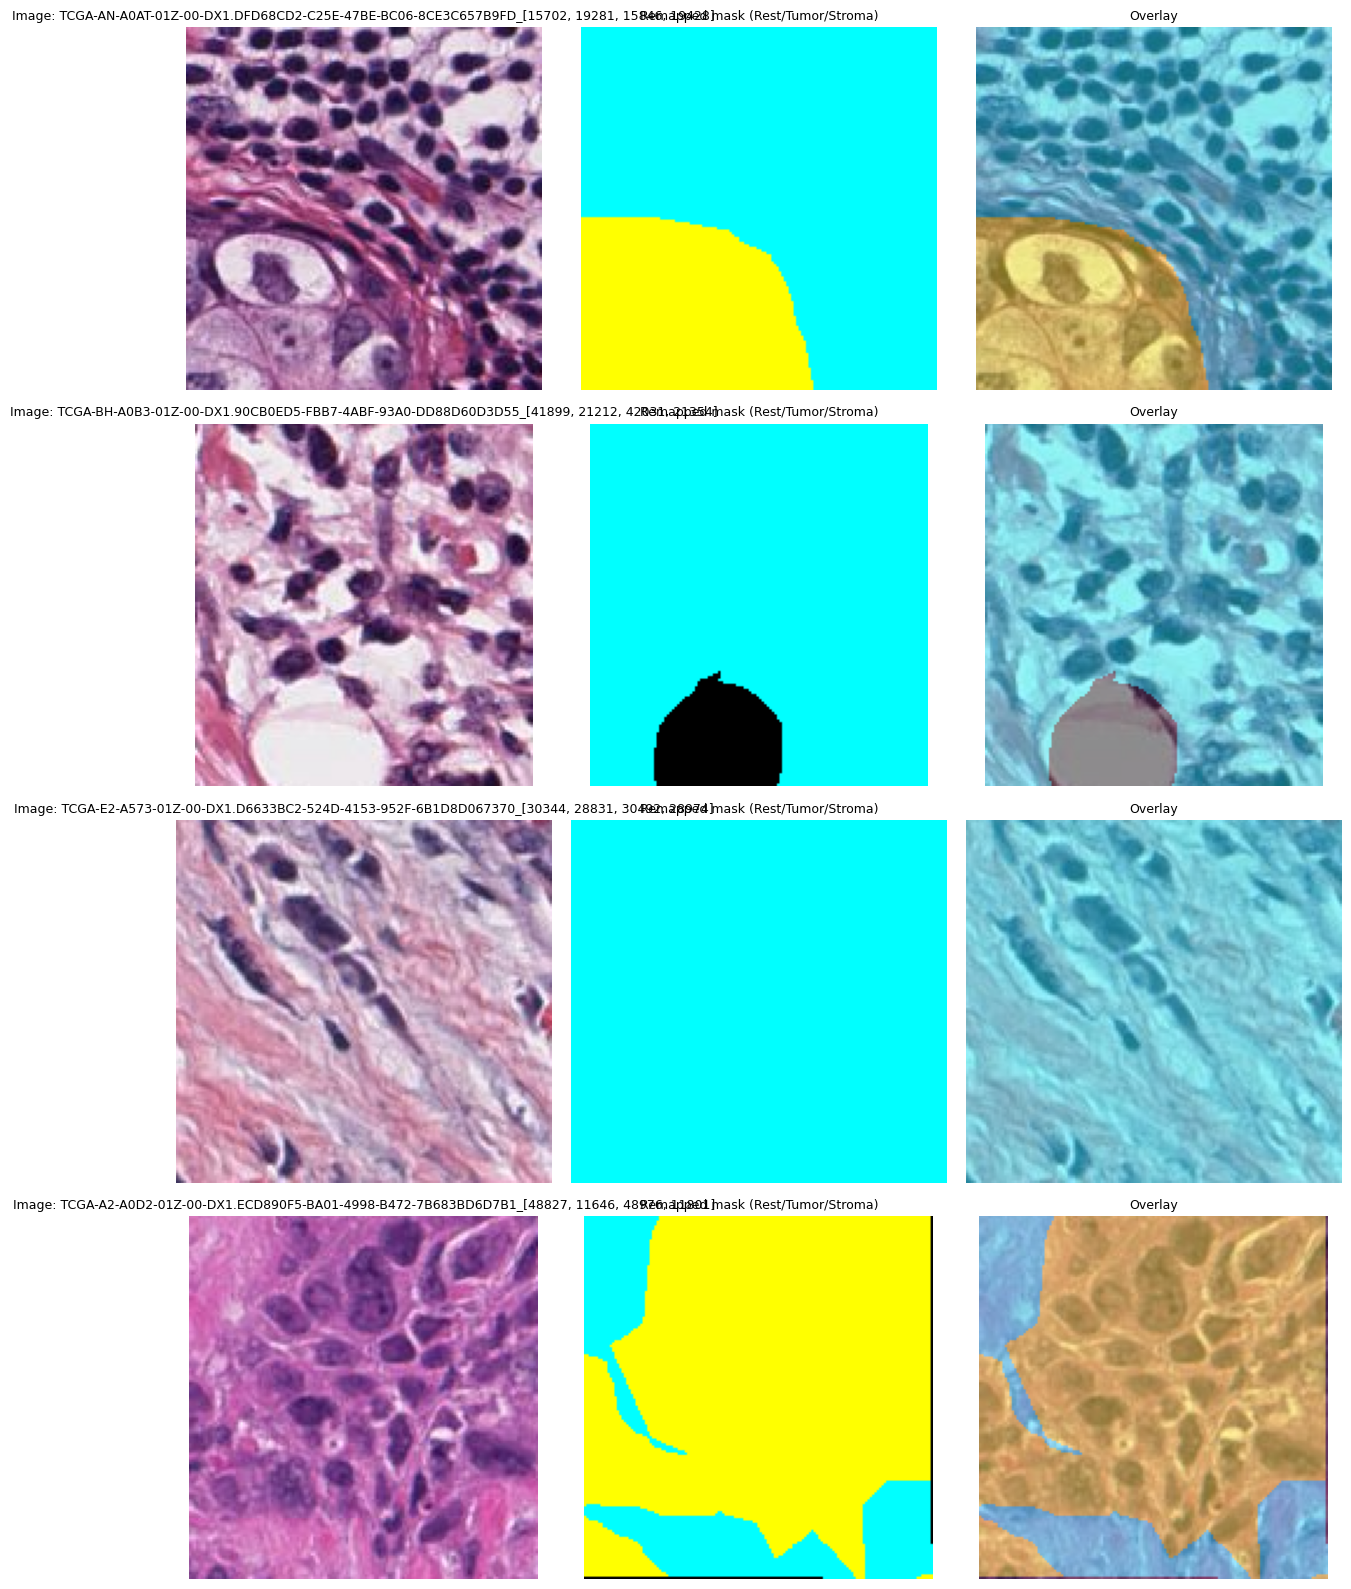

In [ ]:
sample_stems_viz = random.sample(list(matched), min(4, len(matched)))

fig, axes = plt.subplots(len(sample_stems_viz), 3, figsize=(12, 4 * len(sample_stems_viz)))
if len(sample_stems_viz) == 1:
    axes = axes.reshape(1, -1)

cmap = plt.matplotlib.colors.ListedColormap(['black', 'yellow', 'cyan'])  # Rest, Tumor, Stroma

for row, stem in enumerate(sample_stems_viz):
    img_path = image_stems[stem]
    mask_path = mask_stems[stem]

    with s3.open(img_path, 'rb') as f:
        img_bytes = f.read()
    im = Image.open(BytesIO(img_bytes)).convert('RGB')

    raw_mask = load_mask(mask_path)
    remapped = remap_mask(raw_mask)

    axes[row, 0].imshow(im)
    axes[row, 0].set_title(f"Image: {stem}", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(remapped, cmap=cmap, vmin=0, vmax=2)
    axes[row, 1].set_title("Remapped mask (Rest/Tumor/Stroma)", fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(im)
    axes[row, 2].imshow(remapped, cmap=cmap, vmin=0, vmax=2, alpha=0.4)
    axes[row, 2].set_title("Overlay", fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()


## Step 7 — Image/mask size consistency & source breakdown

Confirm masks and their paired images have matching dimensions (a mismatch would break
training), and check the source distribution (RUMC/JB/TCGA) same as the detection track.


In [ ]:
def infer_source(fname):
    basename = os.path.basename(fname)
    if re.match(r"TC_S\d+_P\d+", basename):
        return 'RUMC'
    if basename.startswith('TCGA'):
        return 'TCGA'
    if re.match(r"^\d+[BS]", basename):
        return 'JB'
    return 'unknown'

size_mismatches = []
sources = Counter()

check_stems = random.sample(list(matched), min(100, len(matched)))
for stem in tqdm(check_stems, desc="Checking size consistency"):
    img_path = image_stems[stem]
    mask_path = mask_stems[stem]
    try:
        with s3.open(img_path, 'rb') as f:
            im = Image.open(BytesIO(f.read()))
        with s3.open(mask_path, 'rb') as f:
            mk = Image.open(BytesIO(f.read()))
        if im.size != mk.size:
            size_mismatches.append((stem, im.size, mk.size))
    except Exception:
        pass
    sources[infer_source(stem)] += 1

print(f"Checked {len(check_stems)} image/mask pairs")
print(f"Size mismatches found: {len(size_mismatches)}")
for m in size_mismatches[:10]:
    print(f"  {m}")

print("\nSource breakdown (sampled):")
print(sources)


Checking size consistency:   0%|          | 0/100 [00:00<?, ?it/s]

Checked 100 image/mask pairs
Size mismatches found: 0

Source breakdown (sampled):
Counter({'TCGA': 93, 'JB': 4, 'RUMC': 3})


## Summary & Next Steps

**Dataset Overview:**
- Total matched image/mask pairs: _(see Step 3)_
- Unmatched masks/images: _(see Step 3 — worth investigating before training)_
- Corrupted files: _(see Step 3)_
- Class distribution: _(see Step 5 — use this to decide if weighted/focal loss is needed for UNet)_
- Size mismatches: _(see Step 7 — must resolve before patch extraction)_

**Preprocessing already decided by the paper (not open questions):**
- 256×256 patch extraction
- ImageNet mean/std normalization
- H&E stain normalization (explicit, required for this track)
- 7→3 class remapping (implemented above)

**Next:** Build the Segmentation data-preparation notebook — 256×256 patch extraction, stain normalization, and train/val/test splits — followed by the equivalent Detection data-prep notebook (resize to 512×512, COCO→YOLO conversion).
